# 6 · Queue imbalance and the microprice: a better "fair value" than the mid

**The question:** at any instant, what's the best estimate of the "true" price?

The mid is the standard answer, but it ignores *sizes*. Picture the book:

```
  ask  70,000.1  x   0.3 BTC      <- tiny queue: a few market buys will eat it
  bid  70,000.0  x  25.0 BTC      <- huge queue
```

The mid says 70,000.05. But the ask queue is about to disappear, and then the price ticks *up*. Surely
fair value is closer to 70,000.1?

**Queue imbalance** I = q_bid / (q_bid + q_ask) captures this. Chapter 1 showed BTCUSDT is a large-tick
asset with long queues. That's exactly where imbalance should matter most, because the price can only move
when a queue empties.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from micro.data import load_quotes, TICK
from micro.book import mid, imbalance, weighted_mid, spread_ticks, to_ms, resample_last
from micro.stats import binned_mean, ols
from micro.plotting import style, save, BLUE, ORANGE, GREEN, GREY

style()
quotes = load_quotes()
qts, m = to_ms(quotes.ts), mid(quotes)
I = imbalance(quotes.bid_qty, quotes.ask_qty)
st = spread_ticks(quotes, TICK)

# For every book state: the mid at the NEXT time the mid changes.
changes = np.flatnonzero(np.diff(m) != 0) + 1            # indices where a new mid appears
nxt = np.searchsorted(changes, np.arange(len(m)), side="right")
has_next = nxt < len(changes)
next_mid = np.full(len(m), np.nan)
next_mid[has_next] = m[changes[nxt[has_next]]]
next_move = next_mid - m

# Train on the first 12 hours, test on the last 12. Never evaluate on the data you fitted.
half_day = qts[0] + np.timedelta64(12, "h")
base = (st == 1) & has_next
train, test = base & (qts < half_day), base & (qts >= half_day)
print(f"train states: {train.sum():,}   test states: {test.sum():,}")

train states: 5,484,130   test states: 9,173,910


## Imbalance predicts the direction of the next price move

Out-of-sample: predicting 'up if I > 0.5' gets the next mid move right 75.9% of the time


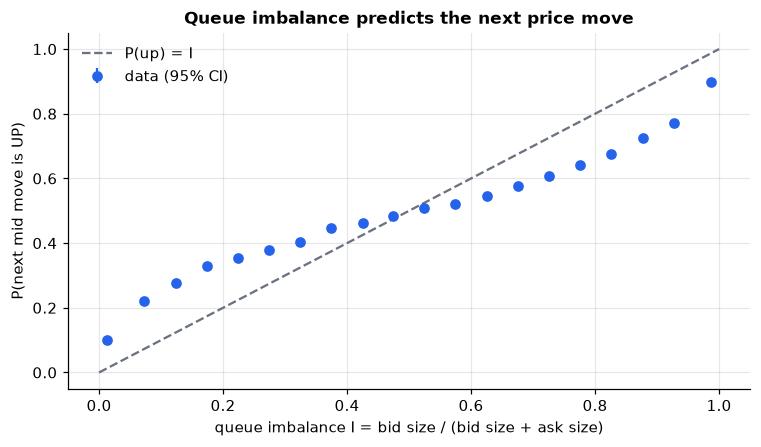

In [2]:
edges = np.linspace(0, 1, 21)
p_up = binned_mean(I[train], (next_move[train] > 0).astype(float), edges)

fig, ax = plt.subplots()
ax.errorbar(p_up.x_mean, p_up.y_mean, yerr=1.96 * p_up.y_se, fmt="o", color=BLUE, label="data (95% CI)")
ax.plot([0, 1], [0, 1], "--", color=GREY, label="P(up) = I")
ax.set(xlabel="queue imbalance I = bid size / (bid size + ask size)", ylabel="P(next mid move is UP)",
       title="Queue imbalance predicts the next price move")
ax.legend()
save(fig, "06_imbalance_direction")

guess_up = I[test] > 0.5
hit = np.mean(guess_up == (next_move[test] > 0))
print(f"Out-of-sample: predicting 'up if I > 0.5' gets the next mid move right {hit:.1%} of the time")

A smooth, monotone, very strong relationship: from ~13% chance of an up-move when the bid queue is tiny to
~87% when the ask queue is tiny. Out of sample, the simple rule "up if I > 0.5" calls the direction of the
next mid change correctly about three times in four.

The curve is *flatter* than the diagonal at the extremes: even with I ≈ 0.99, a down-move happens ~13% of
the time (a big seller can arrive and hit the bid regardless of queue sizes).

**How is this possible in an efficient market?** You can't trade on it directly. To profit from "the price
will tick up", you buy at the ask now and sell at the bid later. You pay a full tick of spread to capture a
move of half a tick in the mid. The signal is real but smaller than the cost of acting on it as a taker.
Makers use it instead: don't leave your ask out when the ask queue is about to be eaten (chapter 4's
adverse selection).

## From direction to fair value: the microprice

Three candidates for "fair value":

| estimator | formula |
|---|---|
| mid | (bid + ask) / 2 |
| weighted mid | I·ask + (1 − I)·bid  =  mid + (I − ½)·spread |
| microprice (1-step, data-driven) | mid + g(I), with g(I) = E[next mid − mid \| I] estimated on the training half |

Stoikov (2018) defines the microprice as the limit of the expected mid after *many* future mid changes,
estimated with a Markov chain on (imbalance, spread) states. We use the simpler one-step version. It keeps the
key idea, "learn the adjustment from data instead of assuming it's linear", and the full version is an
exercise below.

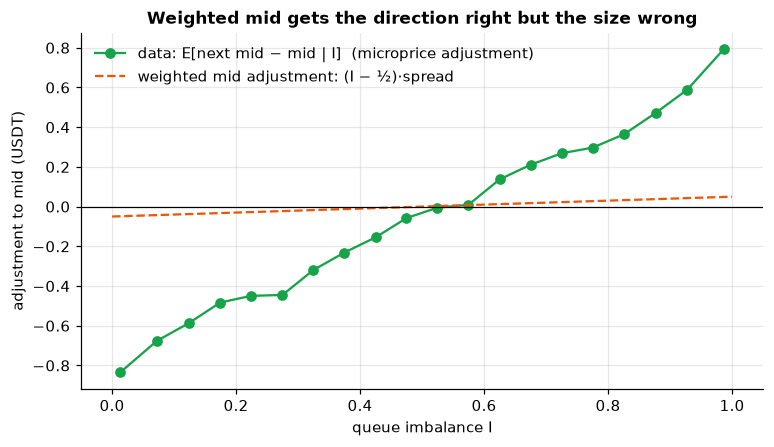

In [3]:
g_table = binned_mean(I[train], next_move[train], edges)
g = g_table.y_mean.to_numpy()
bin_of = np.clip(np.searchsorted(edges, I, side="right") - 1, 0, len(edges) - 2)
microprice = m + g[bin_of]
wmid = weighted_mid(quotes)

fig, ax = plt.subplots()
ax.plot(g_table.x_mean, g_table.y_mean, "o-", color=GREEN, label="data: E[next mid − mid | I]  (microprice adjustment)")
ax.plot(edges, (edges - 0.5) * TICK, "--", color=ORANGE, label="weighted mid adjustment: (I − ½)·spread")
ax.axhline(0, color="black", lw=0.8)
ax.set(xlabel="queue imbalance I", ylabel="adjustment to mid (USDT)", title="Weighted mid gets the direction right but the size wrong")
ax.legend()
save(fig, "06_microprice_adjustment")

The weighted mid's adjustment is at most ±0.05 USDT (half a tick). The data says the expected next move is
up to ±0.8 USDT. When the mid moves, it often moves by more than half a tick: queues empty in bursts, the
spread opens briefly, sweeps go through several levels. The weighted mid has the right shape and the wrong scale.

## Out-of-sample test

A good fair-value estimate P_t should predict where the mid will be later. Compare mean squared errors on
the **test half**, at several horizons.

In [4]:
rows = []
targets = {"next mid change": next_mid}
for h in [100, 1000, 10_000]:
    targets[f"mid in {h / 1000:g}s"] = resample_last(qts, m, qts + np.timedelta64(h, "ms"))
for tname, target in targets.items():
    mse = {name: np.nanmean((target - est)[test] ** 2) for name, est in [("mid", m), ("weighted mid", wmid), ("microprice", microprice)]}
    rows.append({"target": tname, **{f"MSE {k}": v for k, v in mse.items()},
                 "weighted mid vs mid": 1 - mse["weighted mid"] / mse["mid"],
                 "microprice vs mid": 1 - mse["microprice"] / mse["mid"]})
res = pd.DataFrame(rows).set_index("target")
print(res.to_string(float_format=lambda x: f"{x:.4f}" if abs(x) >= 1 else f"{x:.2%}"))

                  MSE mid  MSE weighted mid  MSE microprice  weighted mid vs mid  microprice vs mid
target                                                                                             
next mid change   13.0772           13.0286         12.6857                0.37%              2.99%
mid in 0.1s       12.9713           12.8847         11.9572                0.67%              7.82%
mid in 1s        146.9637          146.7514        143.9208                0.14%              2.07%
mid in 10s      1743.3474         1743.0367       1738.6477                0.02%              0.27%


The microprice beats the mid at every horizon. The gain is largest at short horizons (around 8% of the
squared error at 100 ms) and fades by 10 s, where the unpredictable part of future price moves dominates.
The weighted mid helps much less: right direction, wrong size.

One more check, a **martingale test**. If P_t were the true fair value, the future error (mid later − P_t)
should be unpredictable from anything we know now, including I.

In [5]:
for tname in ["next mid change", "mid in 1s"]:
    fut = targets[tname]
    print(f"target: {tname}")
    for name, est in [("mid", m), ("weighted mid", wmid), ("microprice", microprice)]:
        sel = test & ~np.isnan(fut)
        r = ols((fut - est)[sel][::10], (I - 0.5)[sel][::10], hac_lags=50)   # every 10th state, HAC for overlap
        print(f"  {name:>13}: slope of (target − estimate) on (I − ½) = {r.beta[1]:+.3f}  (t = {r.t[1]:+.1f})")

target: next mid change


            mid: slope of (target − estimate) on (I − ½) = +1.600  (t = +45.8)


   weighted mid: slope of (target − estimate) on (I − ½) = +1.500  (t = +42.9)


     microprice: slope of (target − estimate) on (I − ½) = +0.003  (t = +0.1)
target: mid in 1s


            mid: slope of (target − estimate) on (I − ½) = +6.808  (t = +63.1)


   weighted mid: slope of (target − estimate) on (I − ½) = +6.708  (t = +62.2)


     microprice: slope of (target − estimate) on (I − ½) = +5.211  (t = +48.3)


For the mid, imbalance strongly predicts the error: the mid ignores information sitting in plain sight.

- At the horizon it was trained for (the **next** mid change), the microprice removes essentially all of that
  predictability. Its error is close to unpredictable from I, as a fair value should be.
- At **1 second**, a lot of predictability remains. One second spans several mid changes, and the price keeps
  drifting in the direction the imbalance pointed (order flow is persistent, chapter 2). A one-step
  adjustment can't capture a multi-step drift. That's exactly why Stoikov's full microprice iterates over
  many future mid changes (exercise 2 below).

---
### Interview angle

<details><summary><b>"Bid 99 for 1,000, offer 100 for 10. Where's fair value?"</b></summary>

Not 99.5. The offer is about to be lifted, so fair value is near 100 (the weighted mid gives 99 + 1000/1010 ≈
99.99). In a real interview, also say *why*: the small queue will be depleted first, and when it is, the
price ticks up. Then mention the caveat from this chapter: the empirical adjustment isn't linear in imbalance,
and a large hidden seller can always appear.
</details>

<details><summary><b>"If imbalance predicts the next move 75% of the time, why isn't everyone rich?"</b></summary>

Because acting on it as a taker costs the spread (1 tick), and the expected gain is less than that. The
signal is valuable to makers (avoid being picked off, decide where to queue) and to anyone who has to trade
anyway (time your execution).
</details>

### Try this yourself
1. Condition on spread = 2 ticks as well. Does the relationship change?
2. Implement Stoikov's full microprice: discretise (I, spread) into states, estimate the transition
   probabilities between states and the mid-move distribution, and iterate G_{k+1} = B·G_k until it converges.
   (Paper: Stoikov, *The micro-price: a high-frequency estimator of future prices*, Quantitative Finance 2018.)